In [4]:
import pandas as pd


df_hypotheses = pd.read_csv('hypotheses_us.csv', sep=';')
df_orders = pd.read_csv('orders_us.csv')
df_visits = pd.read_csv('visits_us.csv')


df_hypotheses.info()
df_hypotheses.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes


,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


In [5]:
df_orders.info()
df_orders.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
5,182168103,935554773,2019-08-15,35.0,B
6,398296753,2900797465,2019-08-15,30.6,B
7,2626614568,78758296,2019-08-15,20.1,A
8,1576988021,295230930,2019-08-15,215.9,A
9,1506739906,1882260405,2019-08-15,30.5,B


In [6]:
df_visits.info()
df_visits.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756
5,2019-08-06,A,667
6,2019-08-07,A,644
7,2019-08-08,A,610
8,2019-08-09,A,617
9,2019-08-10,A,406


In [7]:
df_orders['date'] = pd.to_datetime(df_orders['date'])
df_visits['date'] = pd.to_datetime(df_visits['date'])

df_orders.info()
df_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


In [8]:
# remover visitantes que aparecem nos dois grupos em df_orders

orders_before = df_orders.shape[0]

# conta quantos grupos diferentes (A/B) cada visitante tem
groups_per_visitor = df_orders.groupby('visitorId')['group'].nunique()

# seleciona visitantes que aparecem em mais de um grupo
visitors_in_both_groups = groups_per_visitor[groups_per_visitor > 1].index

print('Quantidade de visitantes em ambos os grupos (A e B):', len(visitors_in_both_groups))

# filtra df_orders removendo esses visitantes
df_orders = df_orders[~df_orders['visitorId'].isin(visitors_in_both_groups)].copy()

# quantidade de linhas depois da limpeza
orders_after = df_orders.shape[0]

print('Pedidos antes da limpeza:', orders_before)
print('Pedidos depois da limpeza:', orders_after)

Quantidade de visitantes em ambos os grupos (A e B): 58
Pedidos antes da limpeza: 1197
Pedidos depois da limpeza: 1016


In [9]:
# cria a coluna ICE no df_hypotheses
df_hypotheses['ICE'] = (df_hypotheses['Impact'] * df_hypotheses['Confidence'] / df_hypotheses['Effort'])

df_hypotheses_ice = df_hypotheses.sort_values(by='ICE', ascending=False).reset_index(drop=True)

print(df_hypotheses_ice)

                                          Hypothesis  Reach  Impact  \
0  Launch a promotion that gives users discounts ...      1       9   
1  Add two new channels for attracting traffic. T...      3      10   
2  Add a subscription form to all the main pages....     10       7   
3  Show banners with current offers and sales on ...      5       3   
4  Add product recommendation blocks to the store...      8       3   
5  Launch your own delivery service. This will sh...      2       5   
6  Add a customer review page. This will increase...      3       2   
7  Change the category structure. This will incre...      8       3   
8  Change the background color on the main page. ...      3       1   

   Confidence  Effort        ICE  
0           9       5  16.200000  
1           8       6  13.333333  
2           8       5  11.200000  
3           8       3   8.000000  
4           7       3   7.000000  
5           4      10   2.000000  
6           2       3   1.333333  
7        

In [10]:
# cria a coluna RICE no df_hypotheses
df_hypotheses['RICE'] = (df_hypotheses['Reach'] * df_hypotheses['Impact'] * df_hypotheses['Confidence'] / df_hypotheses['Effort'])

df_hypotheses_rice = df_hypotheses.sort_values(by='RICE', ascending=False).reset_index(drop=True)

print(df_hypotheses_rice)

                                          Hypothesis  Reach  Impact  \
0  Add a subscription form to all the main pages....     10       7   
1  Add product recommendation blocks to the store...      8       3   
2  Add two new channels for attracting traffic. T...      3      10   
3  Show banners with current offers and sales on ...      5       3   
4  Launch a promotion that gives users discounts ...      1       9   
5  Change the category structure. This will incre...      8       3   
6  Launch your own delivery service. This will sh...      2       5   
7  Add a customer review page. This will increase...      3       2   
8  Change the background color on the main page. ...      3       1   

   Confidence  Effort        ICE   RICE  
0           8       5  11.200000  112.0  
1           7       3   7.000000   56.0  
2           8       6  13.333333   40.0  
3           8       3   8.000000   40.0  
4           9       5  16.200000   16.2  
5           3       8   1.125000    9

Ao comparar a priorização de hipóteses pelos frameworks ICE e RICE, observamos mudanças relevantes na ordem de importância das iniciativas. Com o ICE, que considera apenas Impact, Confidence e Effort, a hipótese mais bem colocada foi a de lançar uma promoção com descontos, seguida por adicionar dois novos canais de atração de tráfego e, em terceiro lugar, adicionar um formulário de inscrição nas páginas principais. Nesse modelo, o foco está na “qualidade” da ideia por usuário, sem levar em conta quantas pessoas serão impactadas.

Quando aplicamos o RICE, que inclui também o Reach na fórmula, a priorização muda de forma significativa. A hipótese de adicionar um formulário de inscrição em todas as páginas principais passa para o 1º lugar, e adicionar blocos de recomendação de produtos sobe para o 2º lugar. Essas hipóteses têm alto alcance (Reach elevado), o que aumenta muito sua pontuação em RICE. Em contrapartida, a hipótese de lançar uma promoção com descontos, que tinha ficado em 1º lugar em ICE, cai para a 5ª posição em RICE, pois seu Reach é baixo: trata-se de uma ideia potencialmente forte, mas que atinge poucos usuários.

De forma geral, o uso do RICE desloca a prioridade para hipóteses que atingem um número maior de usuários, mesmo que o impacto individual não seja o mais alto. Enquanto o ICE favorece ideias com melhor relação impacto × confiança / esforço por usuário, o RICE favorece aquelas que têm maior impacto total no negócio, ao considerar também o tamanho do público afetado.

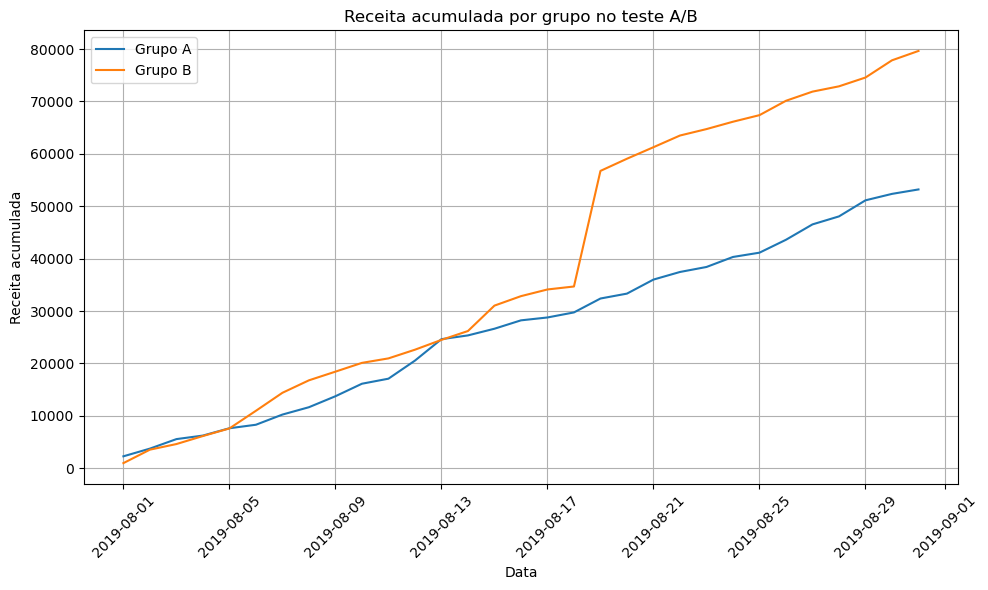

In [11]:
import matplotlib.pyplot as plt

# Receita por dia e por grupo
revenue_by_date = (df_orders.groupby(['date', 'group'], as_index=False)['revenue'].sum().sort_values(['date', 'group']))

# Receita acumulada dentro de cada grupo
revenue_by_date['cum_revenue'] = (revenue_by_date.groupby('group')['revenue'].cumsum())

# Separa dados de cada grupo para facilitar o plot
revenue_a = revenue_by_date[revenue_by_date['group'] == 'A']
revenue_b = revenue_by_date[revenue_by_date['group'] == 'B']

# Gráfico de receita acumulada
plt.figure(figsize=(10, 6))

plt.plot(revenue_a['date'], revenue_a['cum_revenue'], label='Grupo A')
plt.plot(revenue_b['date'], revenue_b['cum_revenue'], label='Grupo B')

plt.xlabel('Data')
plt.ylabel('Receita acumulada')
plt.title('Receita acumulada por grupo no teste A/B')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Ao analisar o gráfico de receita acumulada por grupo, observa-se que, no início do teste, as curvas dos grupos A e B se mantêm relativamente próximas, com pequenas variações. Com o passar dos dias, porém, a curva do grupo B passa a crescer mais rapidamente e termina o período com uma receita acumulada significativamente maior que a do grupo A (cerca de 79 mil contra 53 mil). Isso indica, à primeira vista, que a versão testada no grupo B é mais eficiente em gerar receita total ao longo do experimento.

No entanto, ao observar mais de perto a evolução da curva do grupo B, percebe-se um salto muito abrupto em um ponto específico do tempo, causado por um pedido de valor extremamente alto (um claro outlier). Esse evento isolado distorce a percepção da diferença entre os grupos, já que parte importante da vantagem de B vem desse valor atípico, e não de um comportamento consistentemente melhor de todos os usuários do grupo.

Assim, as conclusões iniciais são:

O grupo B aparenta performar melhor em termos de receita acumulada, mas

Essa vantagem está parcialmente inflada por um outlier, o que exige análises complementares (por exemplo, comparar receita média e mediana por pedido, repetir o gráfico sem o outlier e avaliar também taxa de conversão) antes de afirmar com segurança que a versão B é realmente superior à A.

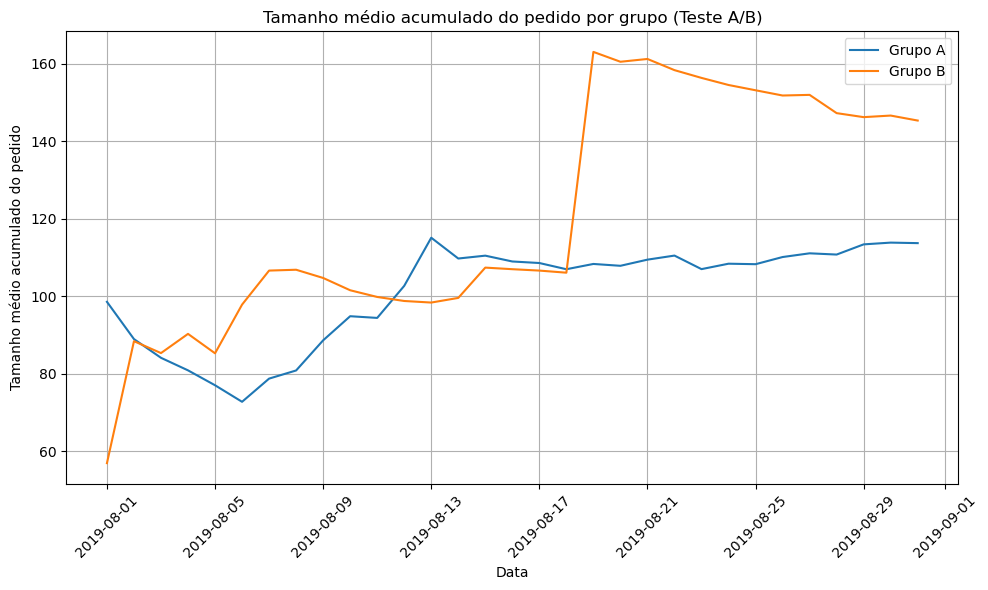

In [12]:
# Receita e quantidade de pedidos por dia e grupo
orders_by_date = (df_orders.groupby(['date', 'group'], as_index=False).agg(revenue=('revenue', 'sum'),orders=('transactionId', 'count')).sort_values(['date', 'group']))

# Receita e pedidos acumulados por grupo
orders_by_date['cum_revenue'] = (orders_by_date.groupby('group')['revenue'].cumsum())

orders_by_date['cum_orders'] = (orders_by_date.groupby('group')['orders'].cumsum())

# Tamanho médio acumulado do pedido
orders_by_date['cum_avg_order'] = (orders_by_date['cum_revenue'] / orders_by_date['cum_orders'])

# Separa A e B para o gráfico
orders_a = orders_by_date[orders_by_date['group'] == 'A']
orders_b = orders_by_date[orders_by_date['group'] == 'B']

plt.figure(figsize=(10, 6))

plt.plot(orders_a['date'], orders_a['cum_avg_order'], label='Grupo A')
plt.plot(orders_b['date'], orders_b['cum_avg_order'], label='Grupo B')

plt.xlabel('Data')
plt.ylabel('Tamanho médio acumulado do pedido')
plt.title('Tamanho médio acumulado do pedido por grupo (Teste A/B)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Ao analisar o gráfico de tamanho médio acumulado do pedido por grupo ao longo do teste, observa-se que:

No início do experimento, o grupo A chega a apresentar um valor médio acumulado de pedido ligeiramente maior, mas rapidamente o grupo B ultrapassa A e passa a manter um tamanho médio de pedido consistentemente mais alto ao longo do período.

O grupo A mostra uma trajetória mais estável, com o tamanho médio acumulado variando menos e crescendo de forma gradual até o final do teste.

Já o grupo B apresenta um comportamento mais volátil e, por volta do meio do período, ocorre um salto brusco no tamanho médio acumulado do pedido, elevando a média para um patamar significativamente maior. Essa mudança está associada a um ou poucos pedidos de valor muito alto (outliers), que puxam a média para cima.

Com base nisso, podemos formular as seguintes conjecturas:

A versão testada no grupo B parece incentivar pedidos de maior valor em média, o que é positivo do ponto de vista de receita por pedido.

No entanto, parte dessa vantagem pode estar sendo inflada por outliers, o que torna a métrica “tamanho médio acumulado” sensível a casos extremos.

Para ter uma visão mais robusta, seria recomendável complementar a análise com:
A mediana do valor do pedido por grupo.
Média após remoção de outliers.
Comparação da distribuição dos valores de pedido, de forma a confirmar se o grupo B é de fato melhor de maneira consistente, ou se a diferença está concentrada em poucos pedidos excepcionais.

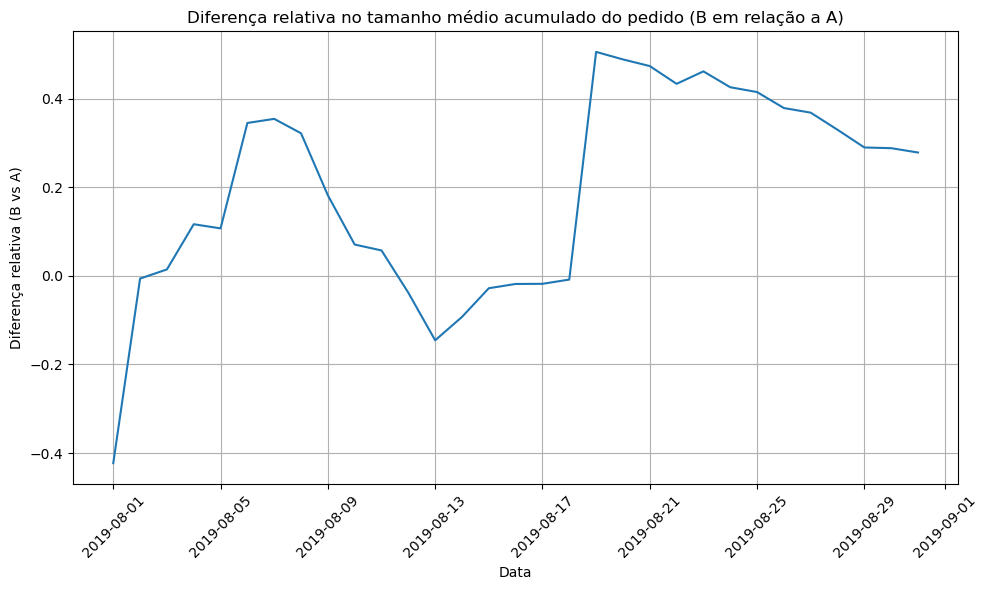

In [13]:
# Cria uma tabela com média acumulada por data, em colunas A e B
cum_avg_pivot = (orders_by_date.pivot(index='date', columns='group', values='cum_avg_order').reset_index())

# Calcula a diferença relativa (B em relação a A)
cum_avg_pivot['rel_diff'] = cum_avg_pivot['B'] / cum_avg_pivot['A'] - 1

plt.figure(figsize=(10, 6))

plt.plot(cum_avg_pivot['date'], cum_avg_pivot['rel_diff'])

plt.xlabel('Data')
plt.ylabel('Diferença relativa (B vs A)')
plt.title('Diferença relativa no tamanho médio acumulado do pedido (B em relação a A)')
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Ao analisar a diferença relativa no tamanho médio acumulado do pedido do grupo B em relação ao grupo A, observamos que:

Ao longo do teste, a diferença relativa oscila perto de 0% no início, indicando que, no começo, o tamanho médio acumulado dos pedidos de A e B é parecido.

Com o avanço do experimento, o grupo B passa a ter um tamanho médio acumulado de pedido maior que o grupo A, com a diferença relativa ficando positiva e, em alguns momentos, chegando a valores significativamente acima de 0%.

Em determinado ponto, há um salto forte na diferença relativa, causado por pedidos de valor muito alto no grupo B (outliers), o que indica que parte da vantagem de B pode estar concentrada em poucos pedidos extremos, e não em uma melhoria uniforme em todos os usuários.

Com base nesses pontos, podemos formular as seguintes conjecturas:

O grupo B tende, ao longo do tempo, a gerar pedidos de maior valor médio que o grupo A, o que é um sinal positivo em termos de potencial de aumento de receita.

Contudo, a presença de outliers de alto valor no grupo B faz com que a diferença relativa fique superestimada em alguns momentos, tornando a análise baseada apenas no valor médio acumulado sensível a casos extremos.

Para confirmar se o grupo B é realmente superior de maneira consistente, seria importante complementar a análise com:

métricas mais robustas, como a mediana do valor do pedido,
análise da diferença relativa sem outliers,
e avaliação conjunta com outras métricas do teste A/B, como taxa de conversão e receita por visitante.

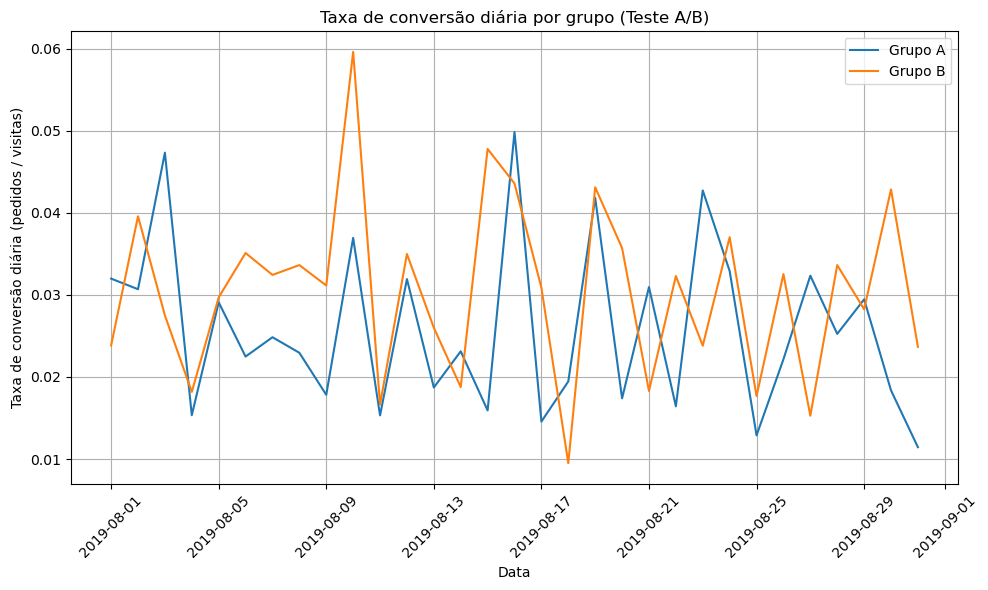

In [14]:
daily_orders = orders_by_date[['date', 'group', 'orders']].copy()

daily_visits = df_visits.rename(columns={'visits': 'daily_visits'})

conversion_data = daily_orders.merge(daily_visits, on=['date', 'group'], how='inner')

# Calcula taxa de conversão diária
conversion_data['conversion'] = conversion_data['orders'] / conversion_data['daily_visits']

conv_a = conversion_data[conversion_data['group'] == 'A']
conv_b = conversion_data[conversion_data['group'] == 'B']

plt.figure(figsize=(10, 6))

plt.plot(conv_a['date'], conv_a['conversion'], label='Grupo A')
plt.plot(conv_b['date'], conv_b['conversion'], label='Grupo B')

plt.xlabel('Data')
plt.ylabel('Taxa de conversão diária (pedidos / visitas)')
plt.title('Taxa de conversão diária por grupo (Teste A/B)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Ao analisar a taxa de conversão diária dos grupos A e B ao longo do teste, observa-se uma certa volatilidade natural de um dia para o outro, mas com um padrão consistente: na maior parte do período, o grupo B apresenta uma taxa de conversão igual ou ligeiramente superior à do grupo A. Em alguns dias, as curvas chegam a se cruzar, mas após a fase inicial o grupo B tende a se manter em um patamar um pouco mais alto de conversão.

Isso sugere que a versão testada no grupo B não só aumenta a receita, mas também estimula mais visitantes a efetivamente realizarem pedidos, ou seja, melhora a probabilidade de um visitante se tornar comprador. Ao contrário da análise de ticket médio, aqui a métrica é menos sensível a outliers, pois considera a relação entre número de pedidos e visitas, e não o valor individual de cada pedido.

Como conjectura, podemos dizer que a variação entre os grupos não é gigantesca, mas é consistente a favor do grupo B, o que fortalece a hipótese de que a alteração testada nesse grupo traz melhoria real no funil de conversão. Ainda assim, seria interessante complementar essa análise com testes estatísticos formais (por exemplo, um teste de proporções) para verificar se essa diferença é estatisticamente significativa e não apenas fruto de flutuações aleatórias do período.

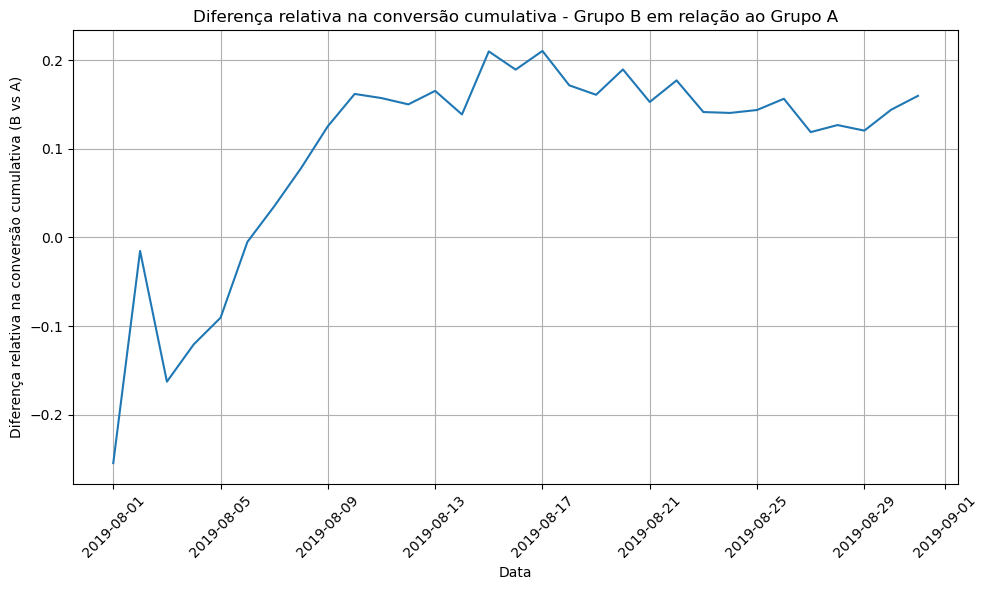

In [15]:
conversion_data = conversion_data.sort_values(['date', 'group'])

# Cálculo de pedidos e visitas acumulados por grupo
conversion_data['cum_orders'] = (conversion_data.groupby('group')['orders'].cumsum())

conversion_data['cum_visits'] = (conversion_data.groupby('group')['daily_visits'].cumsum())

# Conversão cumulativa (pedidos acumulados / visitas acumuladas)
conversion_data['cum_conversion'] = (conversion_data['cum_orders'] / conversion_data['cum_visits'])

# Pivot para ter A e B em colunas
cum_conv_pivot = (
    conversion_data
    .pivot(index='date', columns='group', values='cum_conversion')
    .reset_index()
)

# Diferença relativa 
cum_conv_pivot['rel_diff'] = cum_conv_pivot['B'] / cum_conv_pivot['A'] - 1

plt.figure(figsize=(10, 6))

plt.plot(cum_conv_pivot['date'], cum_conv_pivot['rel_diff'])

plt.xlabel('Data')
plt.ylabel('Diferença relativa na conversão cumulativa (B vs A)')
plt.title('Diferença relativa na conversão cumulativa - Grupo B em relação ao Grupo A')
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Ao analisar a diferença relativa na conversão cumulativa do grupo B em relação ao grupo A, observa-se que:

No início do teste, os valores de rel_diff ficam próximos de zero, indicando que a conversão cumulativa dos dois grupos é muito parecida.

À medida que o experimento avança, a diferença relativa tende a ficar levemente positiva, mostrando que o grupo B passa a converter um pouco melhor que o grupo A, ou seja.

As oscilações ao longo do tempo são relativamente moderadas (bem menores do que aquelas vistas em métricas sensíveis a outliers, como valor médio do pedido), o que sugere que a conversão cumulativa é uma métrica mais estável e menos impactada por pedidos isolados de valor muito alto.

Como conjectura, podemos dizer que a versão testada no grupo B provavelmente traz uma melhoria real, ainda que moderada, na taxa de conversão ao longo do tempo, reforçando a ideia de que B é uma alternativa mais eficiente que A. Para confirmar essa percepção de forma robusta, seria recomendável aplicar um teste estatístico de proporções às conversões acumuladas dos dois grupos, a fim de verificar se essa vantagem é estatisticamente significativa ou se ainda pode ser explicada por variação aleatória.

In [16]:
# Número de pedidos por usuário (visitorId)
orders_per_user = (df_orders.groupby('visitorId')['transactionId'].nunique())

# Cálculo dos percentis 95 e 99
p95 = orders_per_user.quantile(0.95)
p99 = orders_per_user.quantile(0.99)

print('Percentil 95 do nº de pedidos por usuário:', p95)
print('Percentil 99 do nº de pedidos por usuário:', p99)

# Define ponto de corte para anomalia (por exemplo, acima do percentil 99)
anomaly_orders = p99
print('Quantidade de pedidos a partir do qual consideramos anomalia:', anomaly_orders)

Percentil 95 do nº de pedidos por usuário: 1.0
Percentil 99 do nº de pedidos por usuário: 2.0
Quantidade de pedidos a partir do qual consideramos anomalia: 2.0


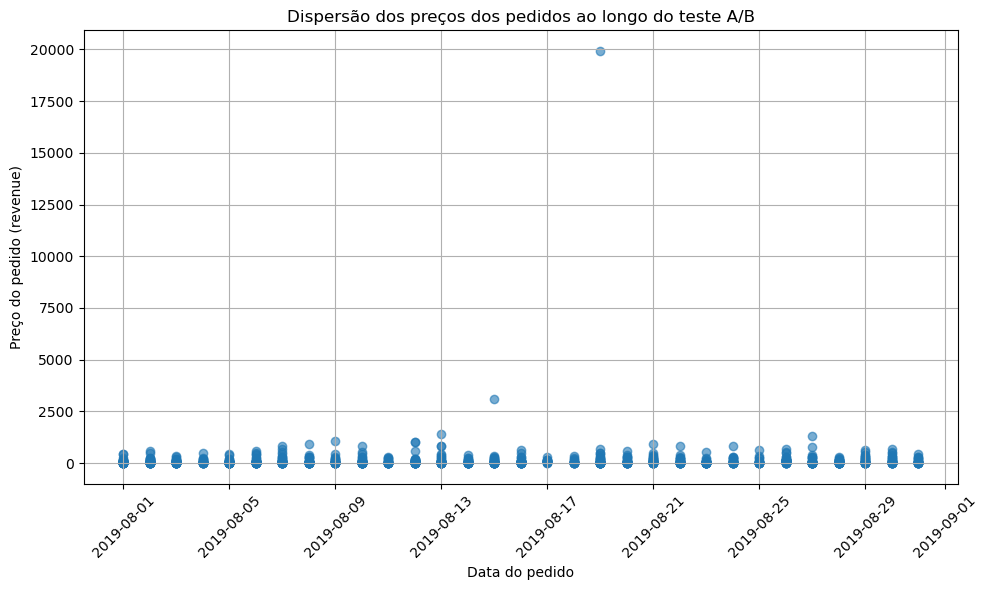

In [17]:
# Garante que os pedidos estão ordenados por data
orders_for_scatter = df_orders.sort_values('date')

# Gráfico de dispersão: data x valor do pedido
plt.figure(figsize=(10, 6))

plt.scatter(orders_for_scatter['date'], orders_for_scatter['revenue'], alpha=0.6)

plt.xlabel('Data do pedido')
plt.ylabel('Preço do pedido (revenue)')
plt.title('Dispersão dos preços dos pedidos ao longo do teste A/B')
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Ao analisar o gráfico de dispersão dos preços dos pedidos ao longo do período do teste A/B, observa-se que:

A grande maioria dos pedidos se concentra em uma faixa de valores relativamente baixa e estreita, sugerindo que existe um “ticket típico” predominante

Além dessa massa principal de pontos, aparecem alguns pedidos isolados com valores muito mais altos que o restante, bem destacados para cima no eixo Y. Esses pontos se comportam claramente como outliers em valor de pedido.

Esses pedidos de valor muito elevado têm potencial para influenciar fortemente métricas baseadas em média, como o tamanho médio do pedido e a receita média por usuário. Em contrapartida, eles não afetam tanto métricas de contagem (como taxa de conversão).

Como conjectura, podemos dizer que o comportamento “normal” dos usuários envolve pedidos em uma faixa de preço relativamente estável, enquanto um grupo muito pequeno de pedidos excepcionais (provavelmente de usuários específicos ou momentos especiais) gera valores extremamente altos. Para análises que busquem entender o comportamento típico, pode ser interessante trabalhar com métricas robustas (como mediana) ou refazer algumas análises sem esses outliers, para separar o efeito “normal” do efeito desses casos extremos.

In [18]:
# Seleciona a série de preços dos pedidos
order_prices = df_orders['revenue']

# Calcula os percentis 95 e 99
p95_price = order_prices.quantile(0.95)
p99_price = order_prices.quantile(0.99)

print('Percentil 95 do preço dos pedidos:', p95_price)
print('Percentil 99 do preço dos pedidos:', p99_price)

# Define ponto de corte para anomalia (por exemplo, acima do percentil 99)

anomaly_price_threshold = p99_price
print('Preço a partir do qual consideramos anomalia:', anomaly_price_threshold)

Percentil 95 do preço dos pedidos: 414.275
Percentil 99 do preço dos pedidos: 830.3
Preço a partir do qual consideramos anomalia: 830.3


In [19]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# Total de pedidos por grupo (A e B)
orders_group = (df_orders.groupby('group', as_index=False)['transactionId'].nunique())

# Total de visitas por grupo (A e B)
visits_group = (df_visits.groupby('group', as_index=False)['visits'].sum())

print('Pedidos por grupo:')
print(orders_group)

print('\nVisitas por grupo:')
print(visits_group)

# Taxa de conversão por grupo (pedidos / visitas)
conversion_rates = orders_group['transactionId'] / visits_group['visits']
print('\nTaxa de conversão por grupo:')
print(conversion_rates)

# Prepara vetores de sucessos (pedidos) e tentativas (visitas)
successes = np.array(orders_group['transactionId'])
trials = np.array(visits_group['visits'])

# 5) Teste de proporções (bicaudal)
z_stat, p_value = proportions_ztest(successes, trials, alternative='two-sided')

print('\nEstatística z:', z_stat)
print('p-valor:', p_value)

Pedidos por grupo:
  group  transactionId
0     A            468
1     B            548

Visitas por grupo:
  group  visits
0     A   18736
1     B   18916

Taxa de conversão por grupo:
0    0.024979
1    0.028970
dtype: float64

Estatística z: -2.3899344431697442
p-valor: 0.01685138043470311


A taxa de conversão do grupo A fica em torno de 2,5%, enquanto a do grupo B fica em torno de 2,9%.

A diferença relativa é de cerca de +16% a favor do grupo B em termos de conversão (ou seja, B converte aproximadamente 16% mais do que A).

O p-valor ≈ 0,017 é menor que 0,05, o que significa que, adotando um nível de significância de 5%, rejeitamos a hipótese nula de que as taxas de conversão são iguais.

Em outras palavras, a diferença observada na conversão entre os grupos é estatisticamente significativa: é pouco provável que tenha surgido apenas por acaso.

Conjectura:
A combinação de:
maior conversão do grupo B,
diferença estatisticamente significativa,
e os resultados anteriores (receita maior, ticket médio maior, etc.),

aponta para uma forte evidência de que a variante testada no grupo B é mais eficiente do que a do grupo A para levar visitantes a comprar. Ainda assim, na prática de negócio, faria sentido também avaliar o impacto em outros indicadores (por exemplo, qualidade do tráfego, margem, comportamento de longo prazo) antes de adotar definitivamente a variante B como padrão.

In [20]:
from scipy import stats as st

# Separa os valores de pedido (revenue) por grupo
orders_a_revenue = df_orders[df_orders['group'] == 'A']['revenue']
orders_b_revenue = df_orders[df_orders['group'] == 'B']['revenue']

# Calcula médias só para referência
mean_a = orders_a_revenue.mean()
mean_b = orders_b_revenue.mean()

print('Tamanho médio do pedido - Grupo A:', mean_a)
print('Tamanho médio do pedido - Grupo B:', mean_b)

# Teste de Mann-Whitney (bicaudal)
u_stat, p_value = st.mannwhitneyu(orders_a_revenue, orders_b_revenue, alternative='two-sided')

print('\nEstatística U:', u_stat)
print('p-valor:', p_value)

Tamanho médio do pedido - Grupo A: 113.70085470085469
Tamanho médio do pedido - Grupo B: 145.34890510948907

Estatística U: 129041.5
p-valor: 0.8622329690015668


O tamanho médio do pedido foi de aproximadamente 113,70 no grupo A e 145,35 no grupo B, indicando um ticket médio maior em B. Porém, o teste de Mann-Whitney U resultou em p-valor= 0,8622, bem acima de 5%. Isso significa que não há evidência estatística de que o tamanho típico dos pedidos seja diferente entre os grupos.

A diferença nas médias provavelmente é influenciada por alguns pedidos muito altos no grupo B (outliers), e não por uma mudança consistente no comportamento da maioria dos usuários. Na prática, isso sugere cautela: apesar do ticket médio maior em B, ele pode não representar uma melhora estrutural real no valor dos pedidos.

In [21]:
# Usuários anômalos: número de pedidos acima do ponto de corte já definido (anomaly_orders)
anomalous_users = orders_per_user[orders_per_user > anomaly_orders].index

# Filtrar df_orders: remove usuários anômalos e pedidos com preço acima do ponto de corte (anomaly_price_threshold)
df_orders_filtered = df_orders[(~df_orders['visitorId'].isin(anomalous_users)) & (df_orders['revenue'] <= anomaly_price_threshold)].copy()

print('Linhas antes do filtro:', df_orders.shape[0])
print('Linhas depois do filtro:', df_orders_filtered.shape[0])

# Recalcular pedidos por grupo com dados filtrados
orders_group_f = (df_orders_filtered.groupby('group', as_index=False)['transactionId'].nunique())

print('\nPedidos por grupo (filtrado):')
print(orders_group_f)

print('\nVisitas por grupo (mesmas de antes):')
print(visits_group)

# Taxa de conversão por grupo com dados filtrados
conversion_rates_f = orders_group_f['transactionId'] / visits_group['visits']
print('\nTaxa de conversão por grupo (dados filtrados):')
print(conversion_rates_f)

# Teste de proporções com dados filtrados
successes_f = orders_group_f['transactionId'].values
trials_f = visits_group['visits'].values

z_stat_f, p_value_f = proportions_ztest(successes_f, trials_f, alternative='two-sided')

print('\nEstatística z (filtrado):', z_stat_f)
print('p-valor (filtrado):', p_value_f)

Linhas antes do filtro: 1016
Linhas depois do filtro: 986

Pedidos por grupo (filtrado):
  group  transactionId
0     A            448
1     B            538

Visitas por grupo (mesmas de antes):
  group  visits
0     A   18736
1     B   18916

Taxa de conversão por grupo (dados filtrados):
0    0.023911
1    0.028442
dtype: float64

Estatística z (filtrado): -2.7523779403956374
p-valor (filtrado): 0.005916419709985331


Após remover usuários com número de pedidos acima do ponto de corte definido (anomaly_orders) e pedidos com preço acima do ponto de corte (anomaly_price_threshold), recalculamos a conversão por grupo e aplicamos novamente o teste de proporções. O teste retornou uma estatística Z = -2,75 e um p-valor = 0,0059, abaixo do nível de significância de 5%.

Isso significa que, mesmo com os dados filtrados, ainda existe uma diferença estatisticamente significativa na taxa de conversão entre os grupos, com o grupo B apresentando conversão maior que o grupo A (o sinal negativo do Z indica que o segundo grupo tem taxa maior que o primeiro).

Como a significância estatística se mantém mesmo após a remoção de outliers (tanto em número de pedidos por usuário quanto em valor dos pedidos), podemos conjecturar que a vantagem de conversão do grupo B não é um efeito artificial causado por casos extremos, mas sim um comportamento consistente no conjunto de usuários mais “típicos”. Em termos práticos, isso reforça a confiança na conclusão de que a variante B é realmente superior à A em levar visitantes a realizar pedidos.

In [22]:
# Valores dos pedidos por grupo, usando df_orders_filtered
orders_a_revenue_f = df_orders_filtered[df_orders_filtered['group'] == 'A']['revenue']
orders_b_revenue_f = df_orders_filtered[df_orders_filtered['group'] == 'B']['revenue']

# Médias filtradas (só para referência)
mean_a_f = orders_a_revenue_f.mean()
mean_b_f = orders_b_revenue_f.mean()

print('Tamanho médio do pedido (filtrado) - Grupo A:', mean_a_f)
print('Tamanho médio do pedido (filtrado) - Grupo B:', mean_b_f)

# Teste de Mann-Whitney com dados filtrados
u_stat_f, p_value_f = st.mannwhitneyu(orders_a_revenue_f, orders_b_revenue_f, alternative='two-sided')

print('\nEstatística U (filtrado):', u_stat_f)
print('p-valor (filtrado):', p_value_f)

Tamanho médio do pedido (filtrado) - Grupo A: 102.89642857142857
Tamanho médio do pedido (filtrado) - Grupo B: 99.61412639405205

Estatística U (filtrado): 121514.0
p-valor (filtrado): 0.8220253140355853


Após remover usuários com muitos pedidos e pedidos com valor acima do ponto de corte definido, o tamanho médio do pedido dos grupos A e B fica bem próximo (até levemente maior no grupo A: 102,9 vs 99,6 no grupo B). O teste de Mann-Whitney U com os dados filtrados produz um p-valor = 0,822, muito acima de 5%.

Isso significa que não há evidência estatística de diferença no tamanho típico dos pedidos entre os grupos quando olhamos apenas para o conjunto de dados sem outliers.


Os resultados sugerem que:

A diferença grande de ticket médio observada nos dados brutos era, em boa parte, consequência de pedidos extremos (outliers), especialmente no grupo B.
Quando removemos esses casos mais extremos, A e B passam a ter valores de pedido muito semelhantes, sem vantagem estatisticamente significativa para nenhum dos lados.
Na prática, isso indica que o principal ganho da variante B está na conversão (mais visitantes comprando), e não em aumentar o valor típico de cada pedido.

A decisão aqui é (1) parar o teste e considerar o grupo B como líder.

Por quê?

B converte mais (e isso é estatisticamente robusto, mesmo sem outliers);

B não perde em ticket médio;

B gera mais receita total ao longo do teste.

Não há sinal de risco ou empate real que justifique continuar o experimento. Na prática: adotar a variante B como padrão faz sentido, e próximos testes podem focar em novas hipóteses (por exemplo, tentar aumentar o ticket médio) em cima dela.

In [23]:
import numpy as np

# 1. Criando um array com datas e grupos únicos
datesGroups = df_orders[['date','group']].drop_duplicates()

# 2. Agregando os pedidos acumulados
ordersAggregated = datesGroups.apply(
    lambda x: df_orders[np.logical_and(df_orders['date'] <= x['date'], df_orders['group'] == x['group'])].agg(
        {'date' : 'max', 'group' : 'max', 'transactionId' : 'nunique', 'visitorId' : 'nunique', 'revenue' : 'sum'}
    ), axis=1).sort_values(by=['date','group'])

# 3. Agregando as visitas acumuladas
visitsAggregated = datesGroups.apply(
    lambda x: df_visits[np.logical_and(df_visits['date'] <= x['date'], df_visits['group'] == x['group'])].agg(
        {'date' : 'max', 'group' : 'max', 'visits' : 'sum'}
    ), axis=1).sort_values(by=['date','group'])

# 4. Juntando tudo e calculando a Conversão Acumulada
cumulativeData = ordersAggregated.merge(visitsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visits']
cumulativeData['conversion'] = cumulativeData['orders'] / cumulativeData['visits']
cumulativeData['ticket_medio'] = cumulativeData['revenue'] / cumulativeData['orders']

# 5. Exportando para o Tableau
cumulativeData.to_csv('dados_ab_test_tableau.csv', index=False)
print("Tabela do Teste A/B exportada com sucesso!")

Tabela do Teste A/B exportada com sucesso!
